# 01_data_overview.ipynb

**Purpose:**  
- Inspect directory layout and sample counts  
- Verify shapes, dtypes, and file consistency  
- Quick‐look at one or two examples of gathers & vp‐models  
- Compute very basic summary stats (min/max, mean, std)  


In [18]:
import os, sys
from glob import glob
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

repo_root = os.path.abspath(os.path.join(os.getcwd(), '..'))
if repo_root not in sys.path:
    sys.path.insert(0, repo_root)

from src.loaders import get_training_ids, get_test_ids

plt.style.use('ggplot')
sns.set_context('notebook')

In [19]:
train_paths, train_ids = get_training_ids()
test_paths, test_ids = get_test_ids()

print(f"🔸 {len(train_ids)} training samples")
print(f"🔸 {len(test_ids)}  test samples")

🔸 2000 training samples
🔸 150  test samples


In [20]:
# Show a quick tree for the first sample
sample = train_paths[0]
print(f"Contents of {sample!r}:")
print(os.listdir(sample))


Contents of '../data/raw/train_data\\00ady8InZofxhWZsDT':
['receiver_data_src_1.npy', 'receiver_data_src_150.npy', 'receiver_data_src_225.npy', 'receiver_data_src_300.npy', 'receiver_data_src_75.npy', 'vp_model.npy']


In [21]:
# load one example
g0 = np.load(os.path.join(sample, 'receiver_data_src_1.npy'))
v0 = np.load(os.path.join(sample, 'vp_model.npy'))

print("Gather shape:", g0.shape,  "dtype:", g0.dtype)
print("VP-model shape:", v0.shape, "dtype:", v0.dtype)

# assert across all samples
for path in train_paths:
    for src in [1,75,150,225,300]:
        assert np.load(f"{path}/receiver_data_src_{src}.npy").shape == (10001,31)
    assert np.load(f"{path}/vp_model.npy").shape == (300,1259)
print("✅ All shapes check out")


Gather shape: (10001, 31) dtype: float32
VP-model shape: (300, 1259) dtype: float64
✅ All shapes check out


(-0.5, 299.5, 1258.5, -0.5)

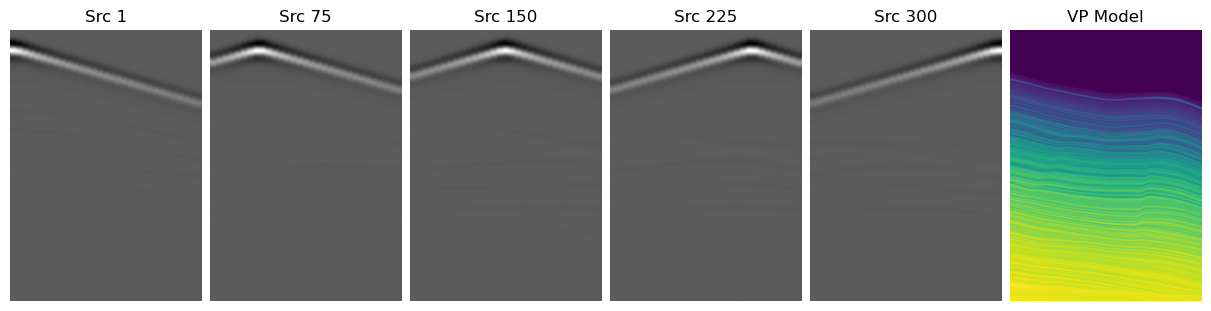

In [22]:
fig, axes = plt.subplots(1, 6, figsize=(12,3), constrained_layout=True)
for i, src in enumerate([1,75,150,225,300]):
    axes[i].imshow(np.load(f"{sample}/receiver_data_src_{src}.npy"), aspect='auto', cmap='gray')
    axes[i].set_title(f"Src {src}")
    axes[i].axis('off')
axes[-1].imshow(np.load(f"{sample}/vp_model.npy").T, aspect='auto', cmap='viridis')
axes[-1].set_title("VP Model")
axes[-1].axis('off')


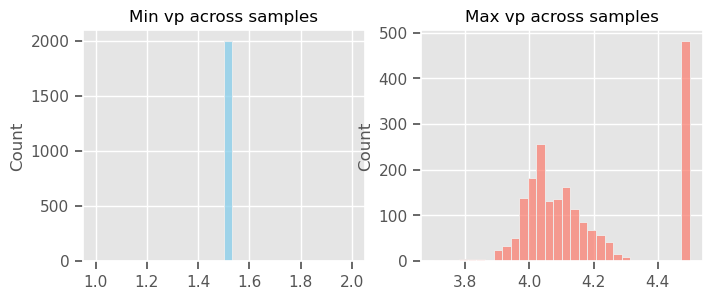

In [23]:
# collect global min/max of all vp_models
mins = [np.load(f"{p}/vp_model.npy").min() for p in train_paths]
maxs = [np.load(f"{p}/vp_model.npy").max() for p in train_paths]

fig, ax = plt.subplots(1,2,figsize=(8,3))
sns.histplot(mins, bins=30, ax=ax[0], color='skyblue'); ax[0].set(title='Min vp across samples')
sns.histplot(maxs, bins=30, ax=ax[1], color='salmon');  ax[1].set(title='Max vp across samples')
plt.show()


All models share the same minimum velocity (1.5 km/s) at the surface, so we’ll focus on the distribution of velocity ranges and maxima to capture geological variability.

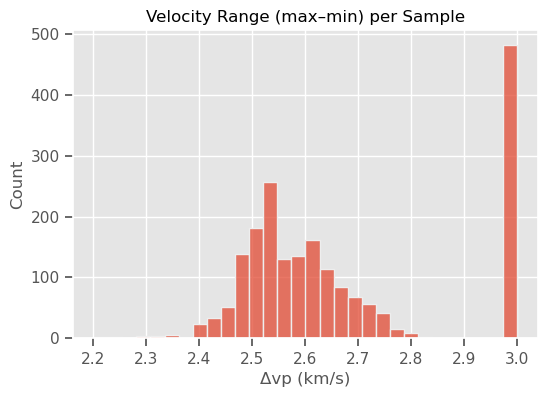

In [24]:
mins = [np.load(f"{p}/vp_model.npy").min() for p in train_paths]
maxs = [np.load(f"{p}/vp_model.npy").max() for p in train_paths]
vrange = [mx - mn for mx, mn in zip(maxs, mins)]

fig, ax = plt.subplots(figsize=(6,4))
sns.histplot(vrange, bins=30, ax=ax)
ax.set_title("Velocity Range (max–min) per Sample")
ax.set_xlabel("Δvp (km/s)")
ax.set_ylabel("Count")
plt.show()


In [25]:
import numpy as np
print("Δvp range stats:",
      f"mean={np.mean(vrange):.2f},",
      f"med={np.median(vrange):.2f},",
      f"5–95%iles={np.percentile(vrange, [5,95])}")


Δvp range stats: mean=2.68, med=2.61, 5–95%iles=[2.45966511 3.        ]


Flag those ids that exceed the velocity range > 2.9 

In [26]:
min_vps, max_vps, ranges = [], [], []
for path in train_paths:
    vp = np.load(os.path.join(path, 'vp_model.npy'))
    vmin, vmax = vp.min(), vp.max()
    min_vps.append(vmin)
    max_vps.append(vmax)
    ranges.append(vmax - vmin)

# 3) Build DataFrame
df_vp = pd.DataFrame({
    'sample_id': train_ids,
    'min_vp':   min_vps,
    'max_vp':   max_vps,
    'range_vp': ranges
})

# 4) Flag those with range_vp greater than threshold
threshold = 2.9  # km/s
df_vp['flagged'] = df_vp['range_vp'] > threshold

# 5) Inspect flagged samples
flagged = df_vp[df_vp['flagged']]
print(f"Samples with Δvp > {threshold} km/s:")
print(flagged[['sample_id', 'min_vp', 'max_vp', 'range_vp']])

flagged[['sample_id']].to_csv('../data/processed/flagged_samples_range_vp_greater_than_2.9.csv', index=False)


Samples with Δvp > 2.9 km/s:
               sample_id  min_vp  max_vp  range_vp
5     09l88467dW9KyDP9x4     1.5     4.5       3.0
13    0PRIDD2lC1JgY31k9s     1.5     4.5       3.0
14    0Qn06ba8uBkxAjxndp     1.5     4.5       3.0
17    0SyQBWJPnin5U6DBlJ     1.5     4.5       3.0
19    0ZvE2atLK5dvafvLFe     1.5     4.5       3.0
...                  ...     ...     ...       ...
1984  zL1A3lArGkYd1yESGX     1.5     4.5       3.0
1985  zMGutp3u5gm943hWMt     1.5     4.5       3.0
1987  zOBXBzauwB3TmELMgE     1.5     4.5       3.0
1998  zoYPgX2AmpFvN1U1uZ     1.5     4.5       3.0
1999  ztCeZ1pvYbmE7ogmmU     1.5     4.5       3.0

[482 rows x 4 columns]


→ 1600 in training split, 400 in validation split


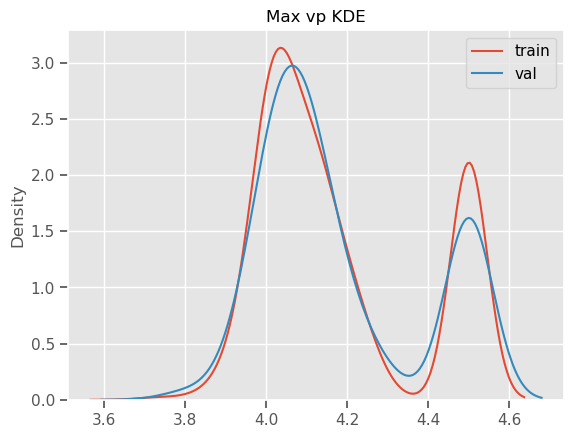

In [27]:
from src.loaders import shuffle_and_split_data

train_ids_split, val_ids_split = shuffle_and_split_data(train_ids, val_ratio=0.2)
print(f"→ {len(train_ids_split)} in training split, {len(val_ids_split)} in validation split")

# Compare a metric (e.g. max vp) between train & val
train_max = [np.load(f"../data/raw/train_data/{i}/vp_model.npy").max() for i in train_ids_split]
val_max   = [np.load(f"../data/raw/train_data/{i}/vp_model.npy").max() for i in val_ids_split]
sns.kdeplot(train_max, label='train'); sns.kdeplot(val_max, label='val'); plt.legend(); plt.title('Max vp KDE'); plt.show()
